# Klasifikasi Penyakit Ginjal Kronis (Chronic Kidney Disease) Menggunakan Machine Learning

## Pendahuluan

Penyakit Ginjal Kronis atau Chronic Kidney Disease (CKD) adalah kondisi ketika fungsi ginjal menurun secara bertahap dalam jangka waktu panjang. CKD merupakan salah satu masalah kesehatan global yang cukup serius karena dapat menimbulkan berbagai komplikasi berat, bahkan berujung pada kematian apabila tidak ditangani secara tepat. Berbagai faktor risiko turut berkontribusi terhadap munculnya CKD, termasuk tekanan darah tinggi, diabetes, anemia, serta kelainan pada darah dan urin.

Dengan kemajuan teknologi, pendekatan machine learning kini banyak dimanfaatkan untuk membantu memprediksi penyakit berdasarkan data medis pasien. Melalui analisis data laboratorium dan kondisi klinis, algoritma machine learning mampu mengenali pola yang sulit diidentifikasi secara manual oleh tenaga medis.

Dalam proyek ini, dilakukan proses klasifikasi penyakit ginjal kronis menggunakan tiga algoritma machine learning, yaitu Logistic Regression, Decision Tree, dan Naive Bayes. Penelitian ini bertujuan untuk membandingkan performa ketiga metode tersebut dalam memprediksi apakah seorang pasien terindikasi menderita penyakit ginjal kronis atau tidak.



## Rumusan Masalah
1. Bagaimana performa algoritma Logistic Regression, Decision Tree, dan Naive bayes dalam mengklasifikasikan penyakit ginjal kronis?
2. Algoritma manakah yang menghasilkan kinerja terbaik berdasarkan nilai evaluasi yang digunakan?


## 3. Tujuan Penelitian
Tujuan dari penelitian ini adalah:
1. Menerapkan metode machine learning untuk melakukan klasifikasi penyakit ginjal kronis.
2. Membandingkan kinerja tiga algoritma, yaitu Logistic Regression, Decision Tree, dan Naive Bayes.
3. Menentukan algoritma terbaik berdasarkan hasil pengujian dan evaluasi.


## 4. Deskripsi Dataset

Dataset yang digunakan dalam penelitian ini adalah Chronic Kidney Disease (CKD) Dataset yang diperoleh dari platform Kaggle. Dataset ini memuat data medis pasien yang mencakup berbagai parameter kesehatan, seperti usia, tekanan darah, kadar gula darah, hasil pemeriksaan urin, serta indikator klinis lainnya. Secara keseluruhan, dataset terdiri dari sekitar 400 data pasien dengan 25 atribut fitur dan 1 label target.

Label target yang digunakan adalah variabel class, yang merepresentasikan kondisi pasien, yaitu:
- 1 : menunjukkan pasien menderita penyakit ginjal kronis (CKD),
- 0 : menunjukkan pasien dalam kondisi normal.

Dataset ini memiliki karakteristik berupa kombinasi data numerik dan kategorikal, serta mengandung sejumlah missing value. Oleh karena itu, diperlukan tahapan data preprocessing terlebih dahulu agar data siap digunakan dalam proses pemodelan machine learning.

## 5. Preprocessing Data

In [1]:
# Import Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)
#Baca Data
df = pd.read_csv("kidney_disease.csv")
# Lihat 5 baris pertama
print("Preview Data:")
display(df.head())

Preview Data:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [3]:
# Bentuk dataset
print("Shape:", df.shape)

Shape: (400, 26)


In [4]:
# Menghilangakn kolom id
df.drop('id', axis = 1, inplace = True)

In [5]:
# Ganti nama Kolom agar mudah di baca
df.rename(columns={
    'age':'age',
    'bp':'blood_pressure',
    'sg':'specific_gravity',
    'al':'albumin',
    'su':'sugar',
    'rbc':'red_blood_cells',
    'pc':'pus_cell',
    'pcc':'pus_cell_clumps',
    'ba':'bacteria',
    'bgr':'blood_glucose_random',
    'bu':'blood_urea',
    'sc':'serum_creatinine',
    'sod':'sodium',
    'pot':'potassium',
    'hemo':'hemoglobin',
    'pcv':'packed_cell_volume',
    'wc':'white_blood_cell_count',
    'rc':'red_blood_cell_count',
    'htn':'hypertension',
    'dm':'diabetes_mellitus',
    'cad':'coronary_artery_disease',
    'appet':'appetite',
    'pe':'pedal_edema',
    'ane':'anemia',
    'classification':'class'
}, inplace=True)

In [6]:
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [7]:
# Statistik dasar
df.describe()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,hemoglobin
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [8]:
# Informasi tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  hemoglobin               3

#### Karena ada tipe data yang tidak sesuai, dimana tabel 'packed_cell_volume', 'white_blood_cell_count' dan 'red_blood_cell_count' itu seharusnya angka, maka harus kita ubah dulu untuk tipe datanya ke numerik

In [9]:
# Mengubah kolom ke numerik
df['packed_cell_volume'] = pd.to_numeric(df['packed_cell_volume'], errors='coerce')
df['white_blood_cell_count'] = pd.to_numeric(df['white_blood_cell_count'], errors='coerce')
df['red_blood_cell_count'] = pd.to_numeric(df['red_blood_cell_count'], errors='coerce')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  hemoglobin               3

#### Mengekstraksi Data

In [11]:
# Mengekstraksi kolom kategorikal dan numerik
kategori = [col for col in df.columns if df[col].dtype == 'object']
numerik = [col for col in df.columns if df[col].dtype != 'object']

In [12]:
# Melihat nilai unik dalam kolom kategorikal
for col in kategori:
    print(f"{col} has {df[col].unique()} values\n")

red_blood_cells has [nan 'normal' 'abnormal'] values

pus_cell has ['normal' 'abnormal' nan] values

pus_cell_clumps has ['notpresent' 'present' nan] values

bacteria has ['notpresent' 'present' nan] values

hypertension has ['yes' 'no' nan] values

diabetes_mellitus has ['yes' 'no' ' yes' '\tno' '\tyes' nan] values

coronary_artery_disease has ['no' 'yes' '\tno' nan] values

appetite has ['good' 'poor' nan] values

pedal_edema has ['no' 'yes' nan] values

anemia has ['no' 'yes' nan] values

class has ['ckd' 'ckd\t' 'notckd'] values



#### Terdapat beberapa ambiguitas pada kolom-kolom tersebut, kita harus menghilangkannya.

In [13]:
# Membenarkan tulisan pada tabel
df['diabetes_mellitus'] = df['diabetes_mellitus'].replace({'\tno':'no','\tyes':'yes', ' yes':'yes'})

df['coronary_artery_disease'] = df['coronary_artery_disease'].replace({'\tno': 'no'})

df['class'] = df['class'].replace({'ckd\t': 'ckd', 'notckd': 'not ckd'})

In [14]:
# Mengubah 'ckd' menjadi 1 dan 'not ckd' menjadi 0
df['class'] = df['class'].map({'ckd': 1, 'not ckd': 0})

In [15]:
for col in kategori:
    print(f"{col} has {df[col].unique()} values\n")

red_blood_cells has [nan 'normal' 'abnormal'] values

pus_cell has ['normal' 'abnormal' nan] values

pus_cell_clumps has ['notpresent' 'present' nan] values

bacteria has ['notpresent' 'present' nan] values

hypertension has ['yes' 'no' nan] values

diabetes_mellitus has ['yes' 'no' nan] values

coronary_artery_disease has ['no' 'yes' nan] values

appetite has ['good' 'poor' nan] values

pedal_edema has ['no' 'yes' nan] values

anemia has ['no' 'yes' nan] values

class has [1 0] values



#### Memperbaiki nilai yang kosong

In [16]:
# Cek data yang kosong
df.isna().sum().sort_values(ascending = False)

red_blood_cells            152
red_blood_cell_count       131
white_blood_cell_count     106
potassium                   88
sodium                      87
packed_cell_volume          71
pus_cell                    65
hemoglobin                  52
sugar                       49
specific_gravity            47
albumin                     46
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
blood_pressure              12
age                          9
pus_cell_clumps              4
bacteria                     4
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
pedal_edema                  1
anemia                       1
class                        0
dtype: int64

In [17]:
df[numerik].isnull().sum()

age                         9
blood_pressure             12
specific_gravity           47
albumin                    46
sugar                      49
blood_glucose_random       44
blood_urea                 19
serum_creatinine           17
sodium                     87
potassium                  88
hemoglobin                 52
packed_cell_volume         71
white_blood_cell_count    106
red_blood_cell_count      131
dtype: int64

In [18]:
df[kategori].isnull().sum()

red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
pedal_edema                  1
anemia                       1
class                        0
dtype: int64

#### Mengisi nilai kosong atau null pada data numerik

In [19]:
# Mengisi data yang kosong menggunakan median
for col in numerik:
    df[col] = df[col].fillna(df[col].median())

In [20]:
df[numerik].isnull().sum()

age                       0
blood_pressure            0
specific_gravity          0
albumin                   0
sugar                     0
blood_glucose_random      0
blood_urea                0
serum_creatinine          0
sodium                    0
potassium                 0
hemoglobin                0
packed_cell_volume        0
white_blood_cell_count    0
red_blood_cell_count      0
dtype: int64

#### Mengisi nilai kosong atau null pada data kategori

In [21]:
# Mengisi data yang kosong dengan modus
for col in kategori:
    df[col] = df[col].fillna(df[col].mode()[0])

In [22]:
df[kategori].isnull().sum()

red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
pedal_edema                0
anemia                     0
class                      0
dtype: int64

### Matriks Kolerasi

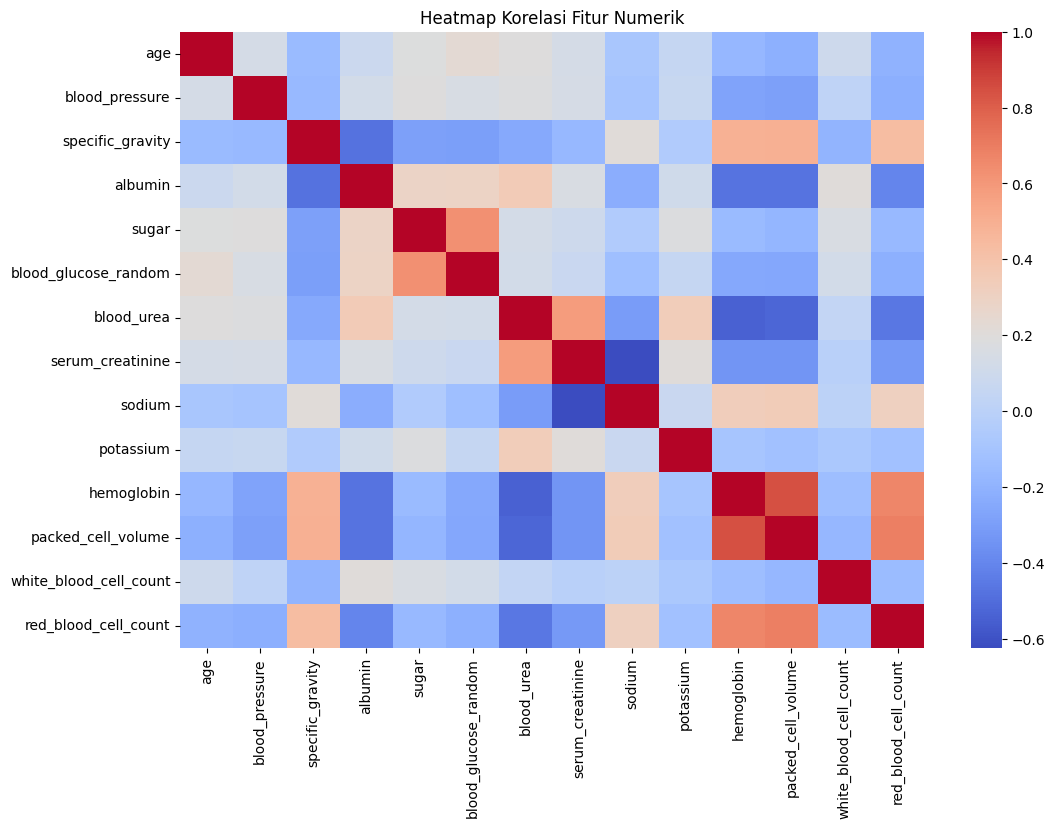

In [23]:
plt.figure(figsize=(12,8))
sns.heatmap(df[numerik].corr(), cmap='coolwarm')
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()


### Data Visualization

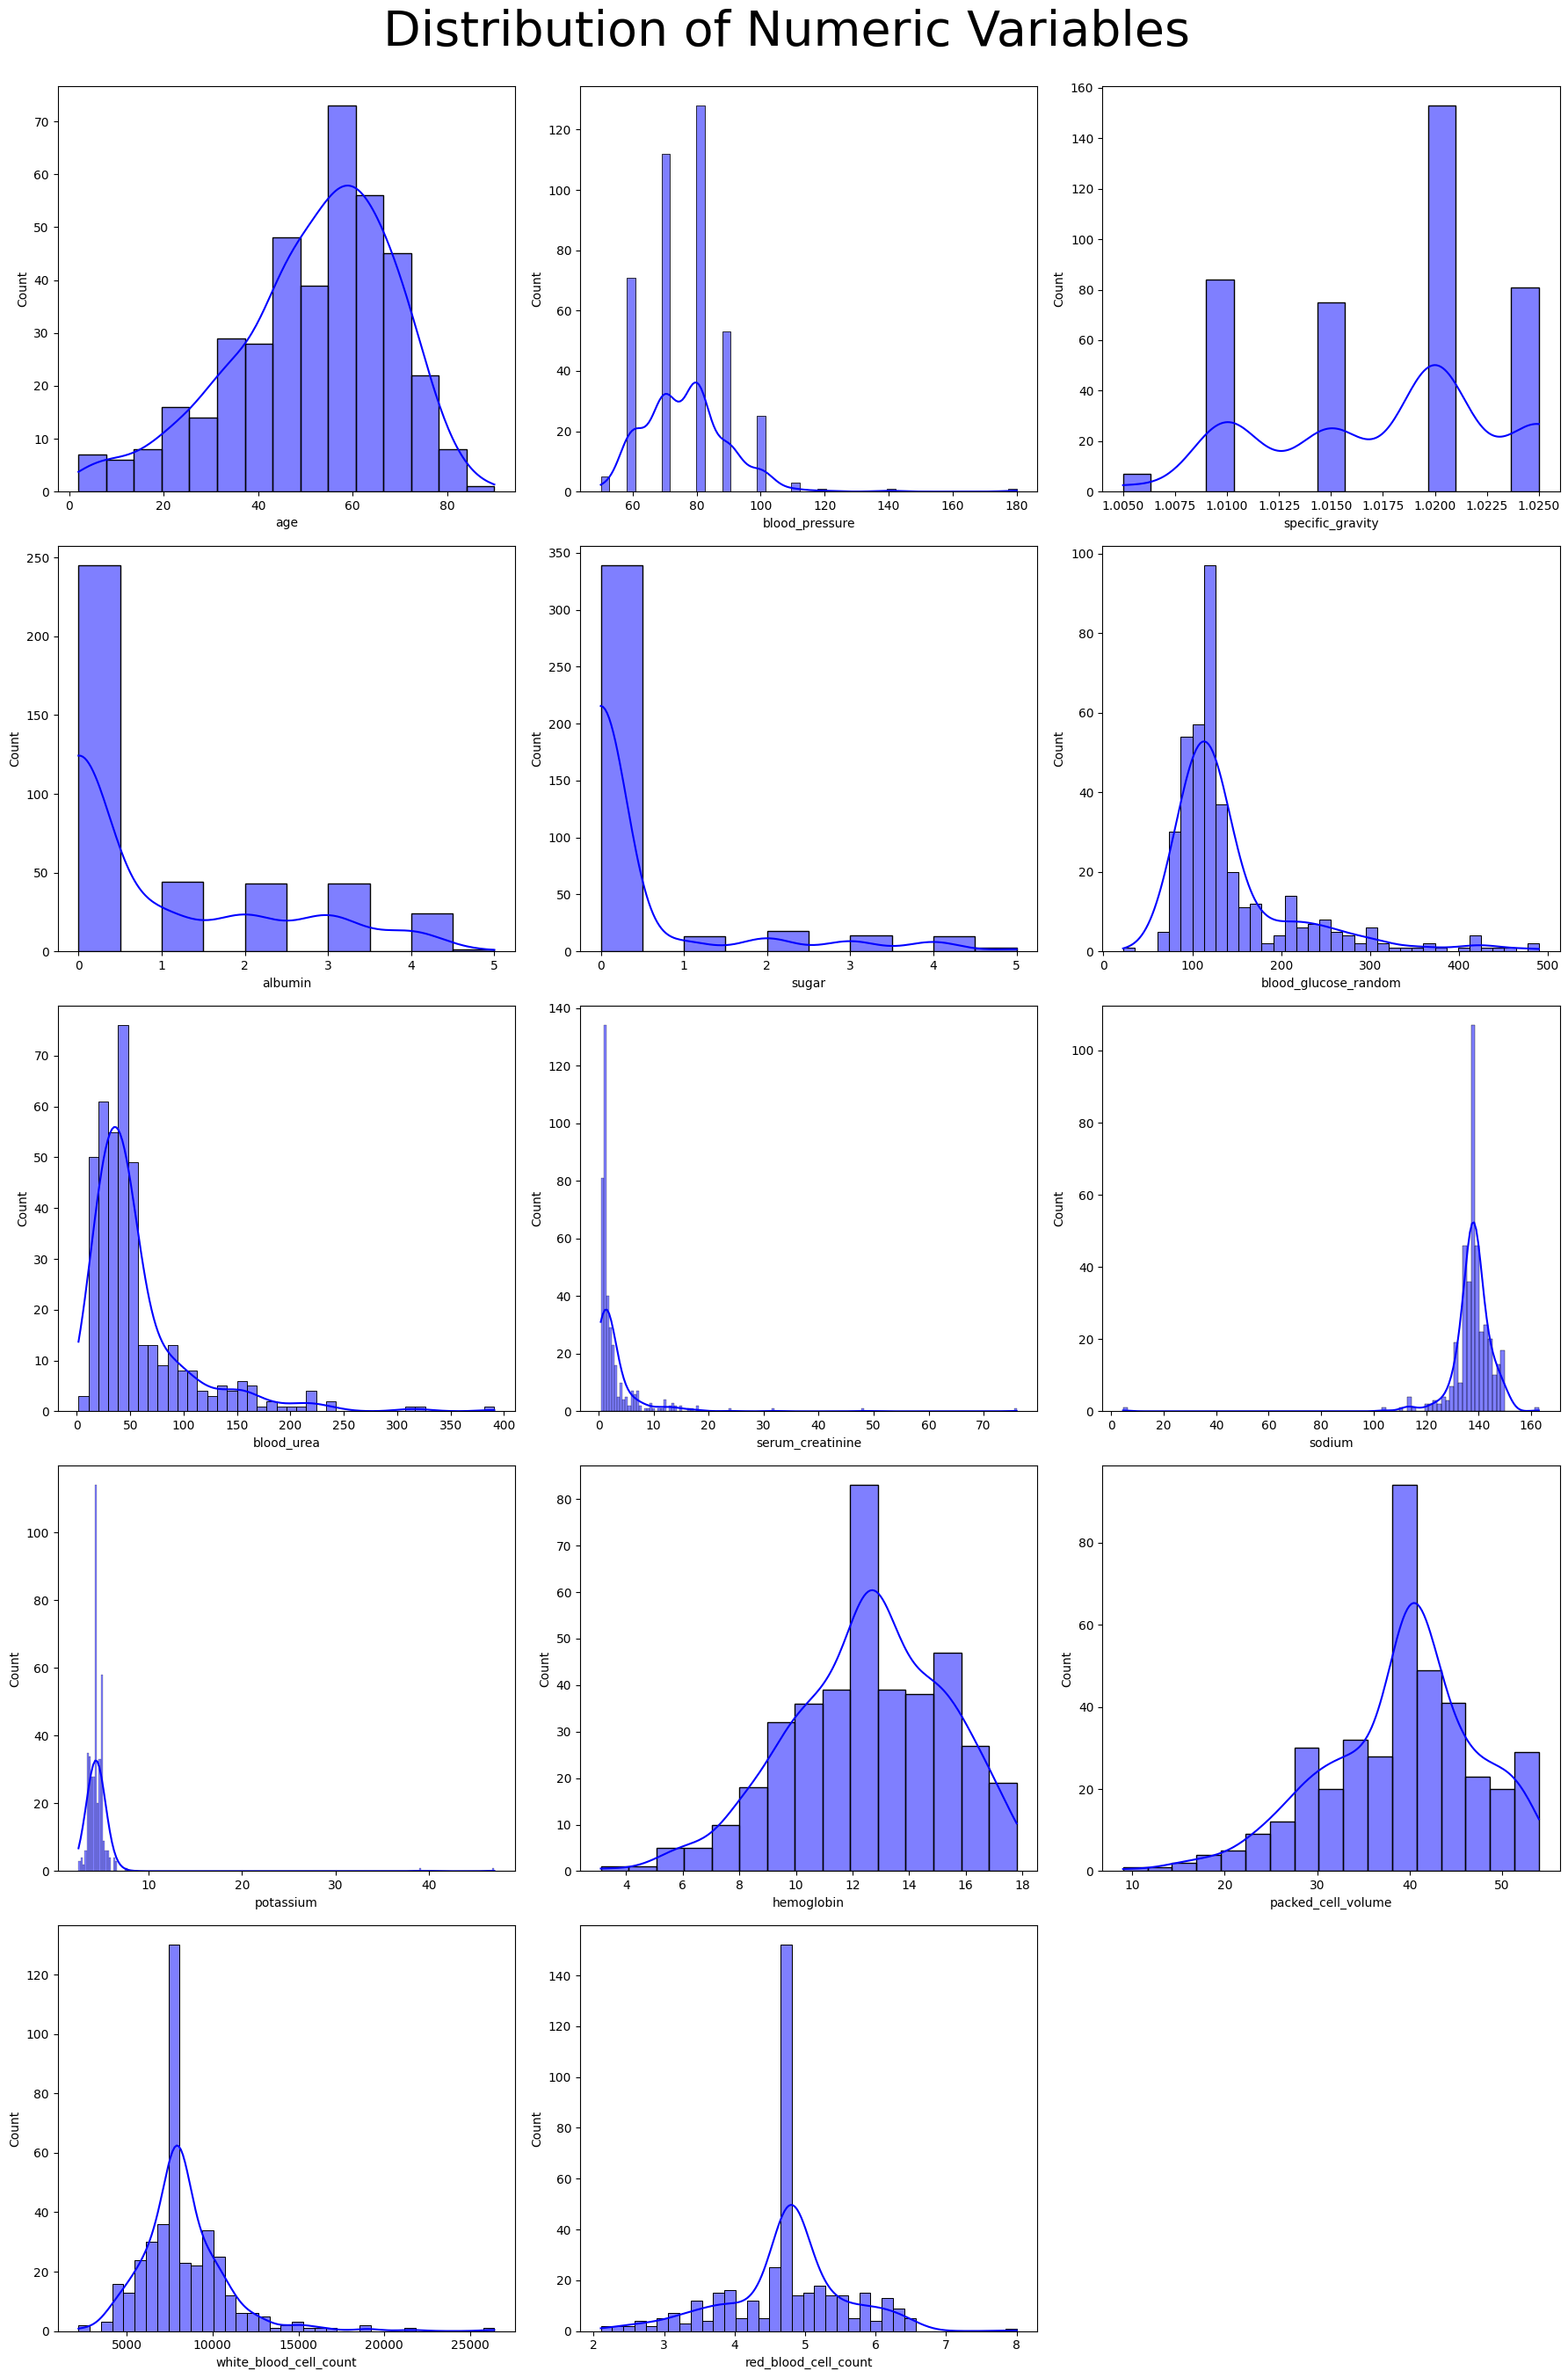

In [24]:
plt.figure(figsize=(18, 27))
plotnumber = 1

for col in numerik:
    if plotnumber <= len(numerik):
        ax = plt.subplot(5, 3, plotnumber)
        sns.histplot(x=df[col], kde=True, color='blue')
        plt.xlabel(col)
        
    plotnumber += 1

plt.suptitle('Distribution of Numeric Variables', fontsize=40, y=1)
plt.tight_layout()
plt.show()


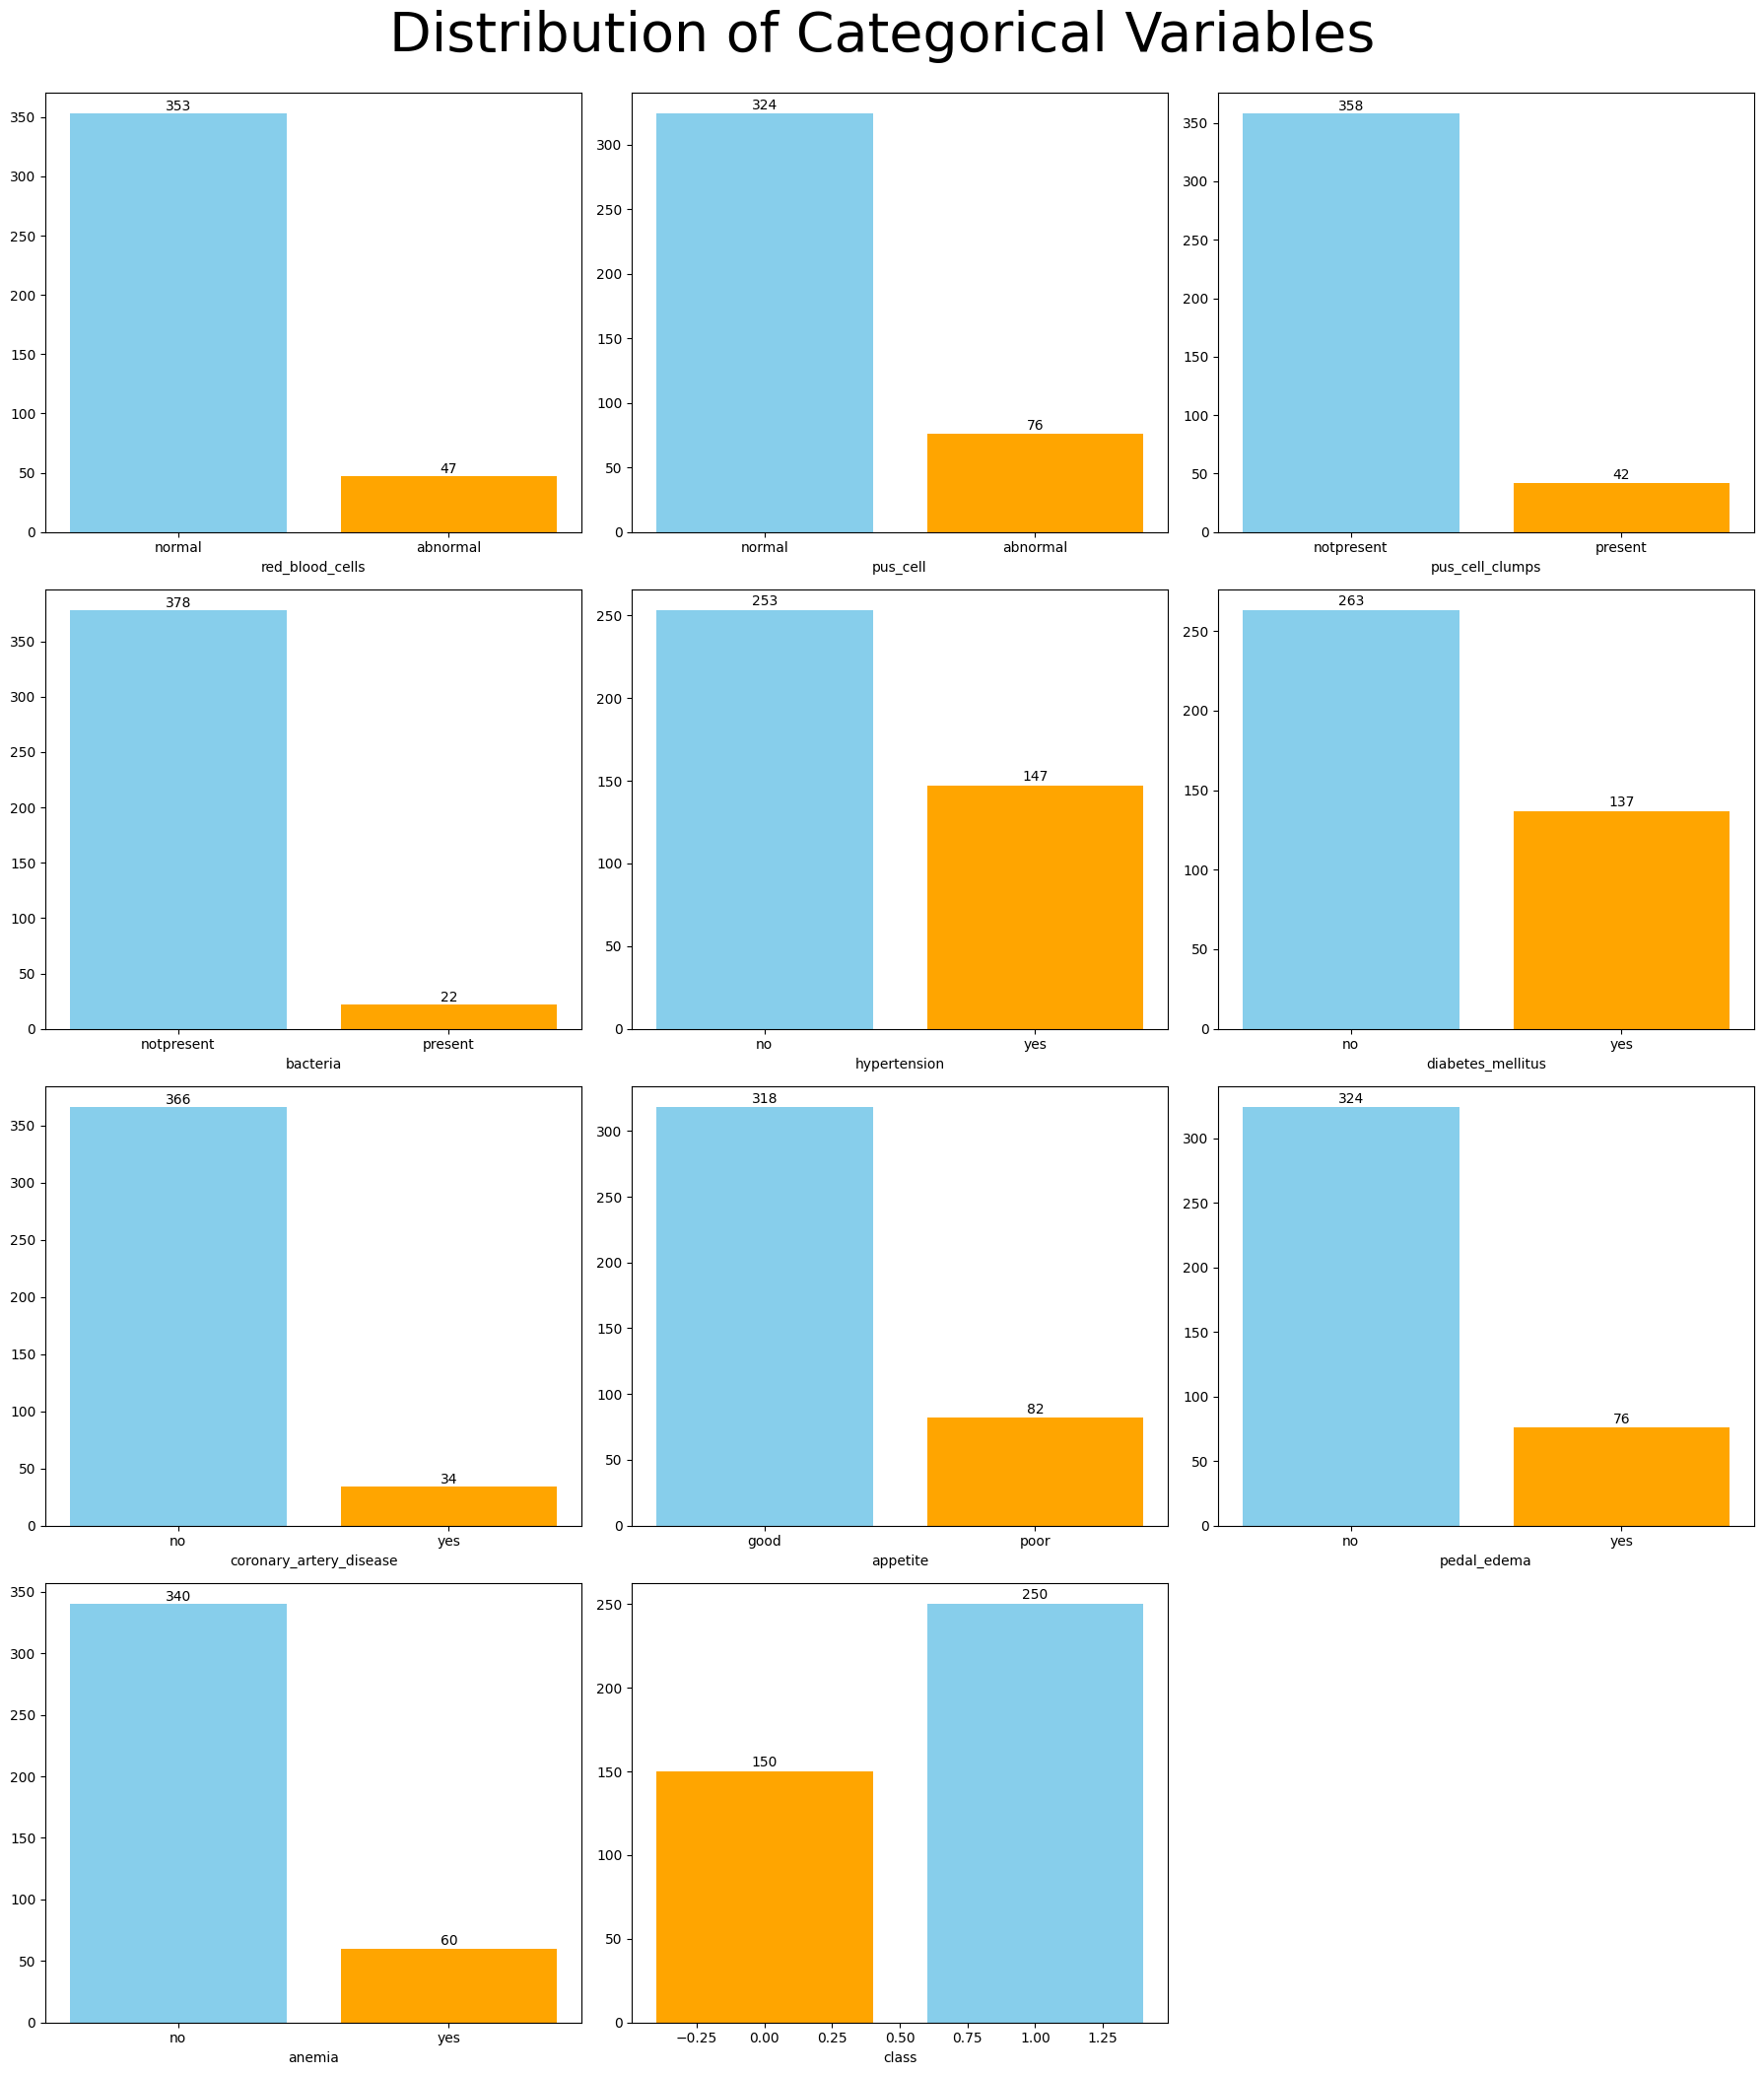

In [25]:
plt.figure(figsize=(18, 21))
plotnumber = 1

colors = ['skyblue', 'orange', 'lightgreen', 'salmon', 'lightcoral', 'cyan', 'pink']

for col in kategori:
    if plotnumber <= len(kategori):
        ax = plt.subplot(4, 3, plotnumber)
        # sns.countplot(x=df[col], palette = 'pastel')
        counts = df[col].value_counts()
        ax.bar(counts.index, counts.values, color=colors[:len(counts)])
        
        # Add labels to each bar in the plot
        for p in ax.patches:
            ax.text(p.get_x()+p.get_width()/2, p.get_height()+3, f'{p.get_height()}', ha="center")
        
        plt.xlabel(col)
        
    plotnumber += 1

plt.suptitle('Distribution of Categorical Variables', fontsize=40, y=1)
plt.tight_layout()
plt.show()

#### Memeriksa apakah data memiliki outlier

#### Karena data terlalu besar skalanya jadi dibagi menjadi per kelompok agar semua box terlihat

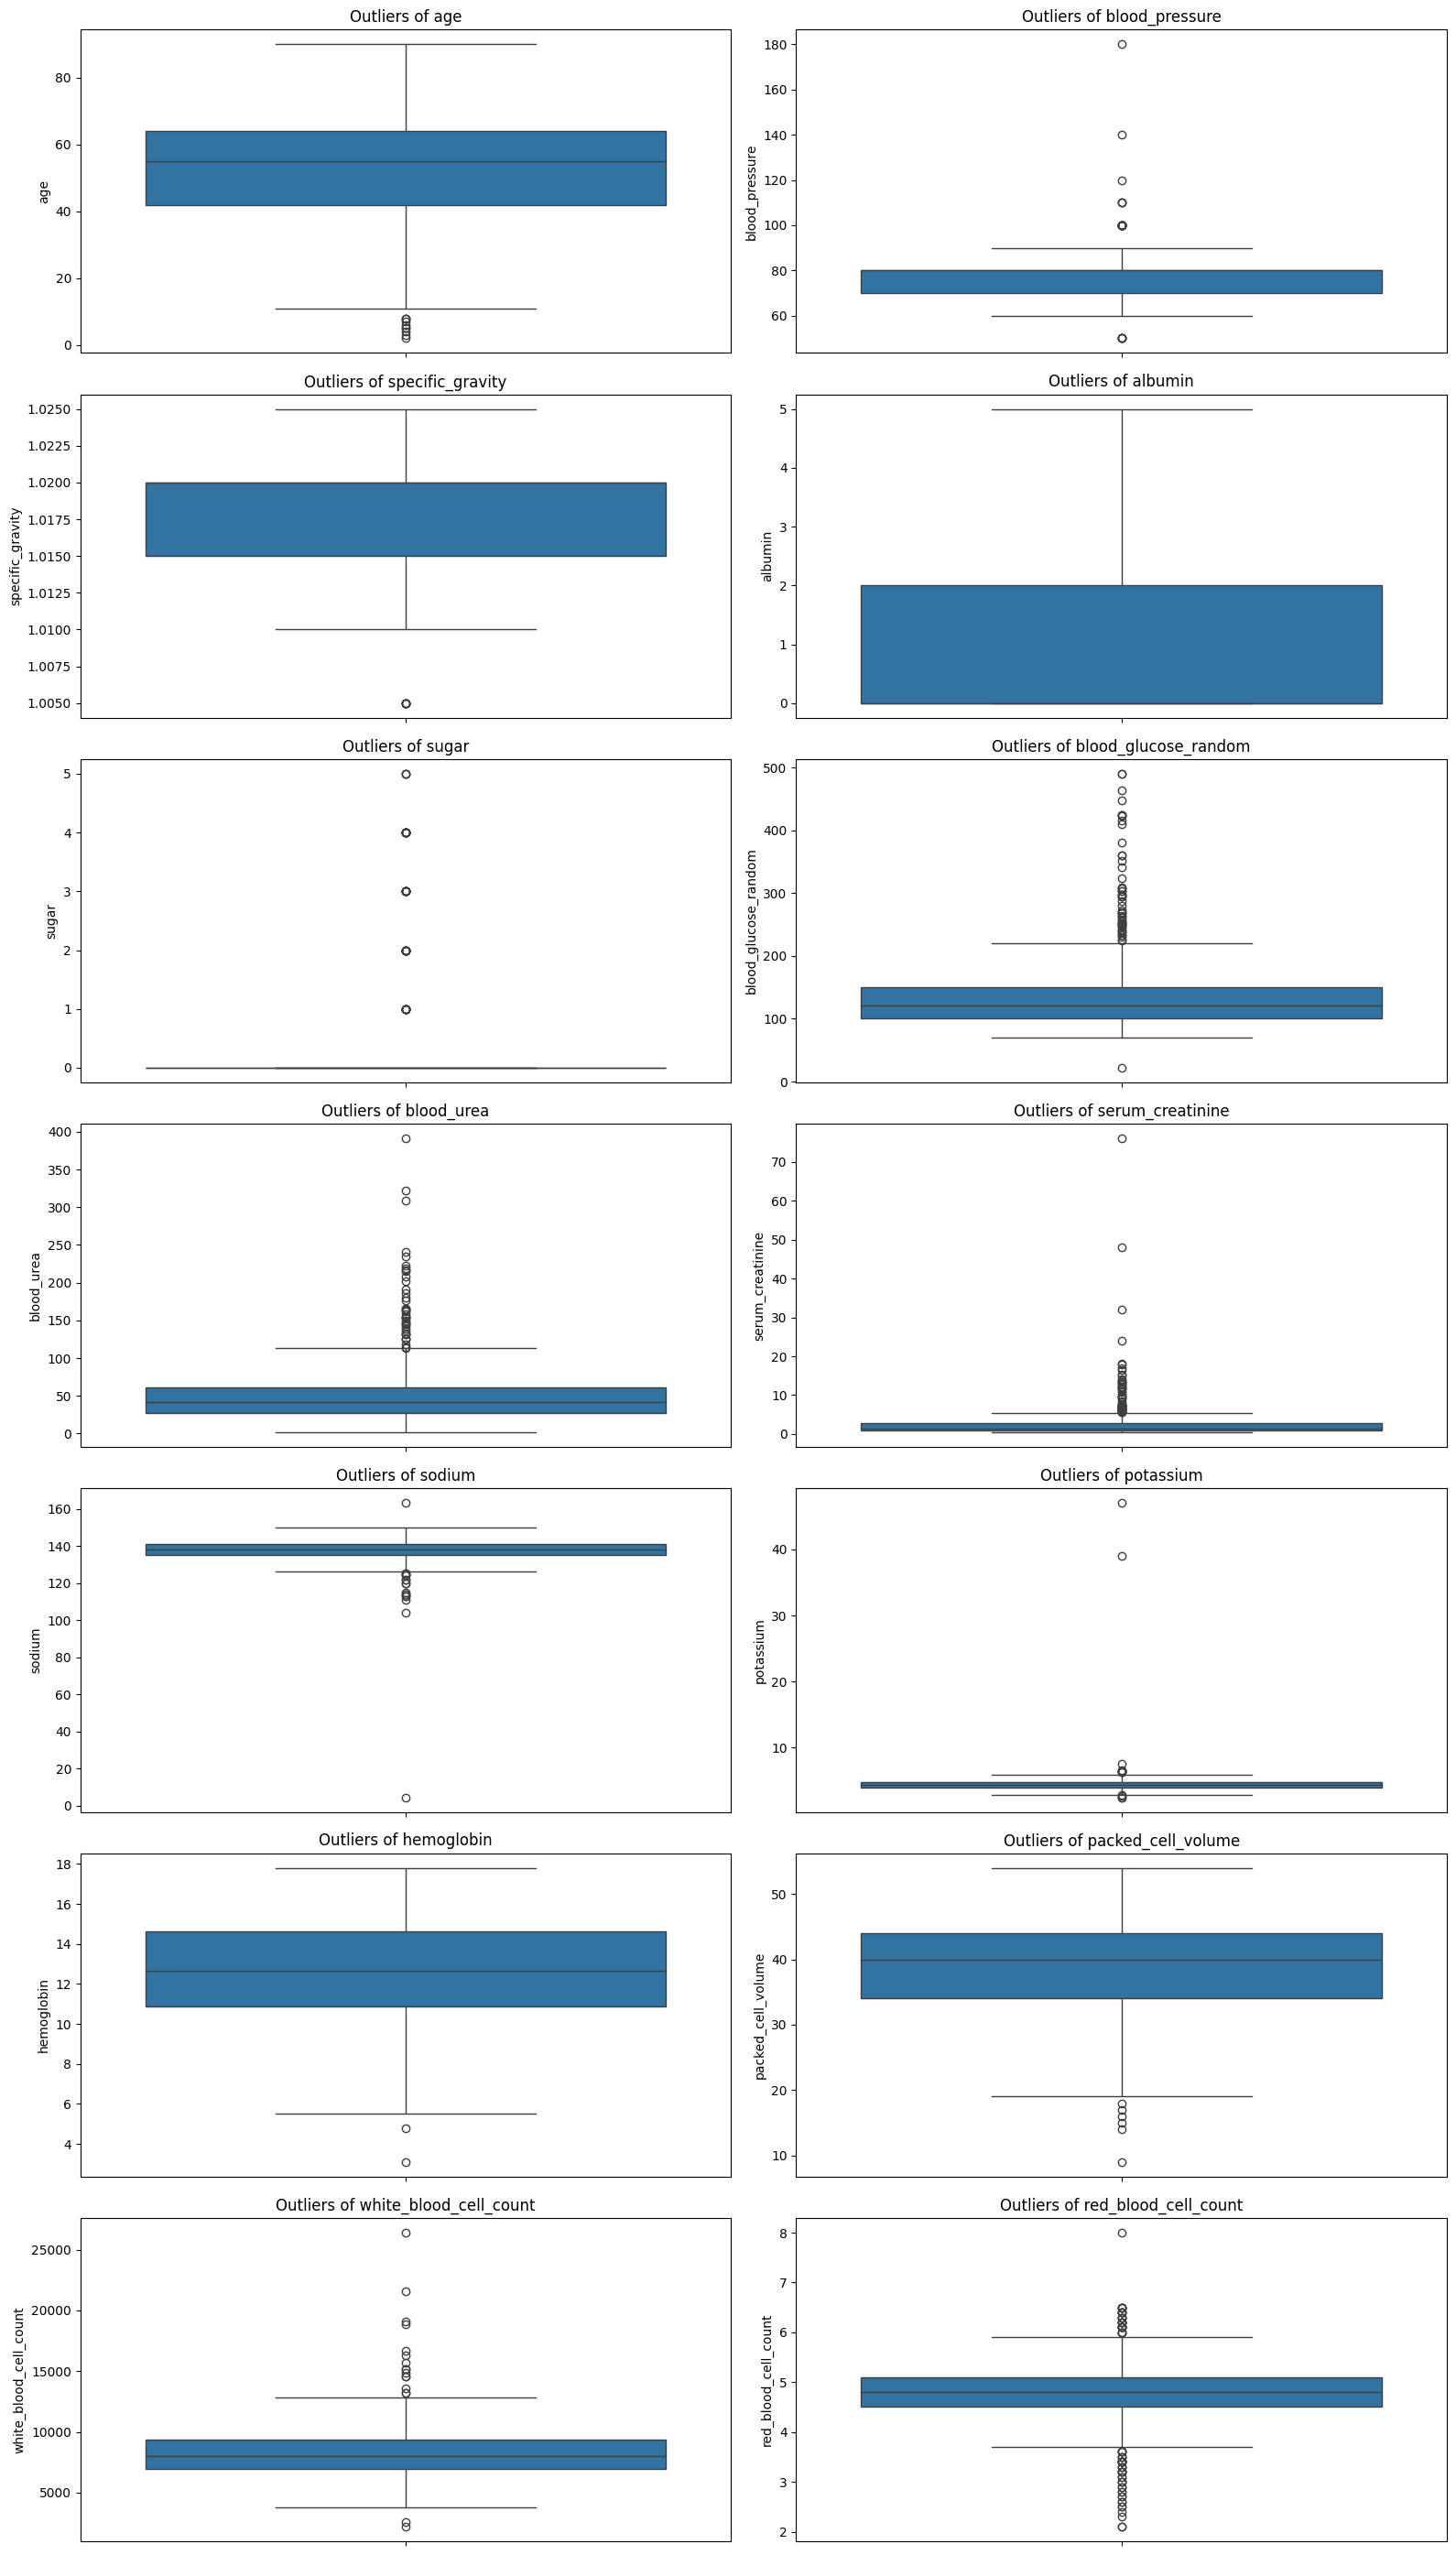

In [26]:
numerical_cols = numerik 

n = len(numerical_cols)
columns = 2
rows = (n + 1) // columns

plt.figure(figsize=(16, 4 * rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, columns, i)
    sns.boxplot(y=df[col])
    plt.title(f'Outliers of {col}')

plt.tight_layout()
plt.show()

In [27]:
df.shape

(400, 25)

#### Penghapusan outlier

In [28]:
# Sebagian Outlier di hapus
dfA = df.copy()

outlier_cols_A = [
    'blood_pressure',
    'blood_glucose_random',
    'blood_urea',
    'serum_creatinine',
    'white_blood_cell_count'
]

for col in outlier_cols_A:
    Q1 = dfA[col].quantile(0.25)
    Q3 = dfA[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    dfA = dfA[(dfA[col] >= lower) & (dfA[col] <= upper)]


In [29]:
df0 = df.copy()

In [30]:
# Semua outlier di hapus
dfB = df.copy()

for col in numerik:
    Q1 = dfB[col].quantile(0.25)
    Q3 = dfB[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    dfB = dfB[(dfB[col] >= lower) & (dfB[col] <= upper)]


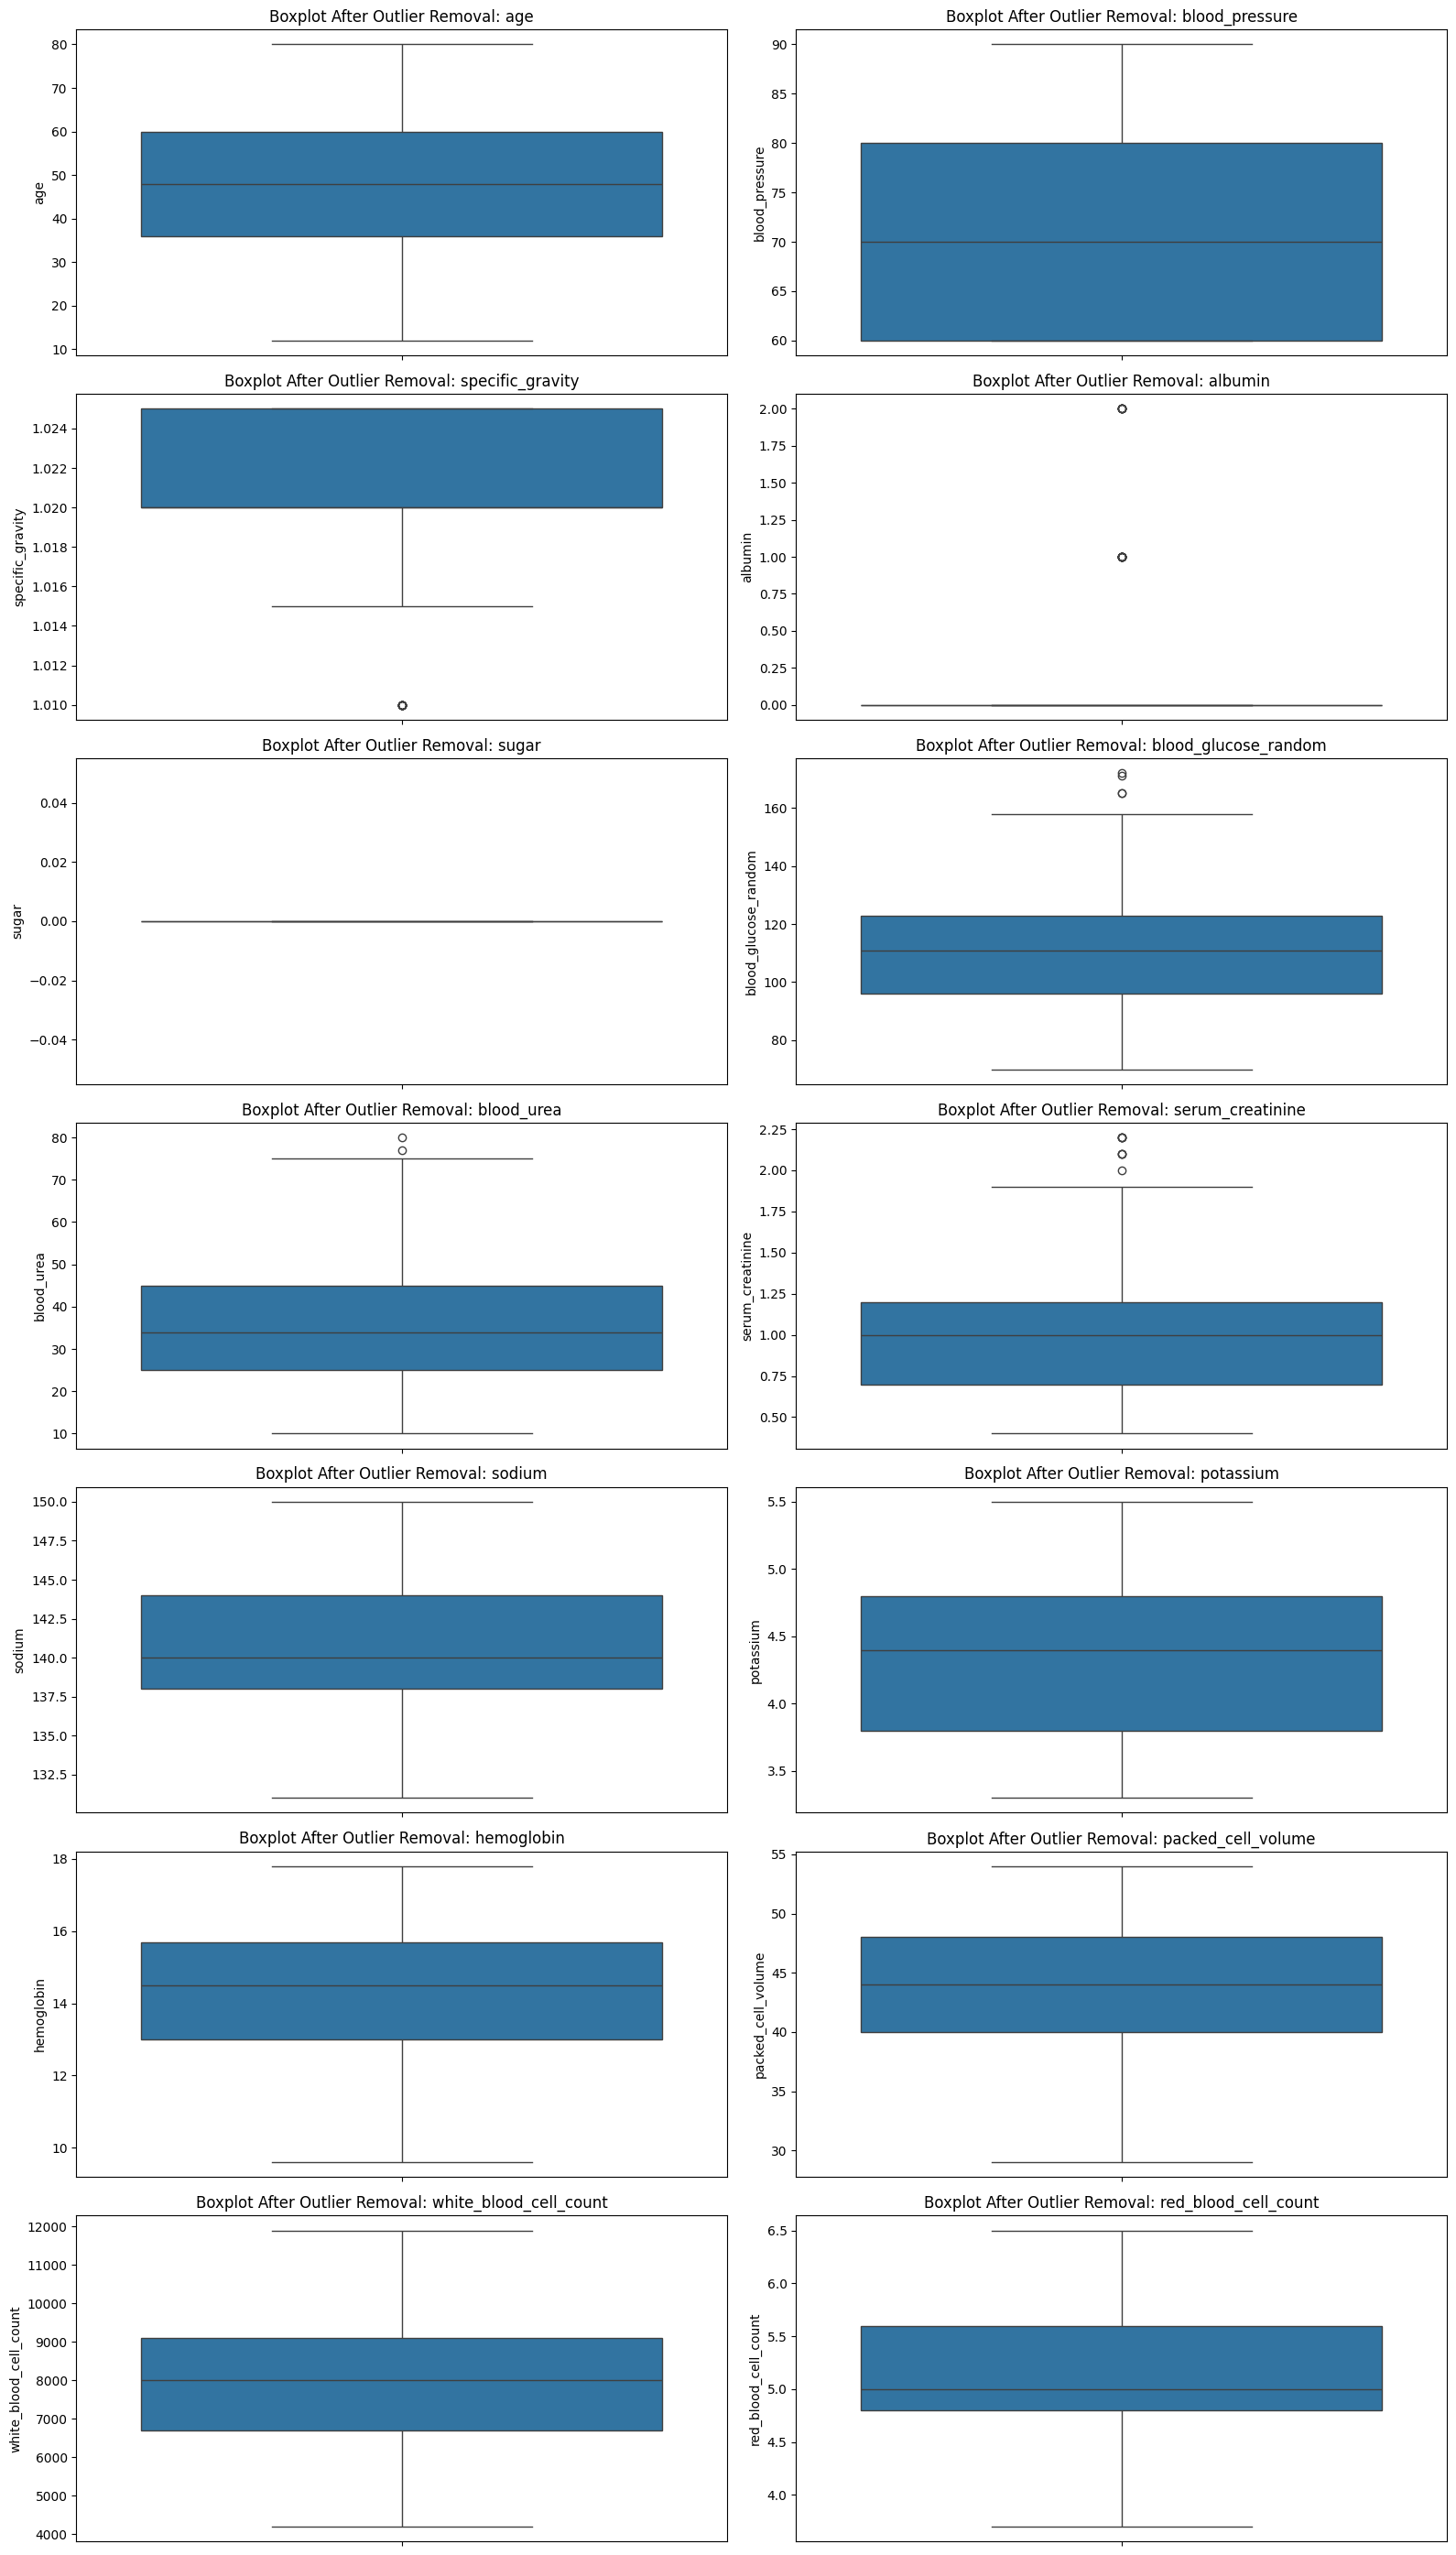

In [31]:
numerical_cols = [col for col in numerik if col != 'class']

n = len(numerical_cols)
columns = 2
rows = (n + 1) // columns

plt.figure(figsize=(16, 4 * rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, columns, i)
    sns.boxplot(y=dfB[col])
    plt.title(f'Boxplot After Outlier Removal: {col}')

plt.tight_layout()
plt.show()

In [32]:
df0.shape

(400, 25)

In [33]:
dfA.shape

(233, 25)

In [34]:
dfB.shape

(197, 25)

In [35]:
df0['class'].value_counts()

class
1    250
0    150
Name: count, dtype: int64

In [36]:
dfA['class'].value_counts()

class
0    150
1     83
Name: count, dtype: int64

In [37]:
dfB['class'].value_counts()

class
0    150
1     47
Name: count, dtype: int64

#### Encoding Data Kategorikal

In [38]:
for c in kategori:
    print(c, ":", df0[c].unique())

red_blood_cells : ['normal' 'abnormal']
pus_cell : ['normal' 'abnormal']
pus_cell_clumps : ['notpresent' 'present']
bacteria : ['notpresent' 'present']
hypertension : ['yes' 'no']
diabetes_mellitus : ['yes' 'no']
coronary_artery_disease : ['no' 'yes']
appetite : ['good' 'poor']
pedal_edema : ['no' 'yes']
anemia : ['no' 'yes']
class : [1 0]


In [39]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
df0_enc = df0.copy()
dfA_enc = dfA.copy()
dfB_enc = dfB.copy()

for col in kategori:
    le = LabelEncoder()
    df0_enc[col] = le.fit_transform(df0_enc[col].astype(str))
    encoders[col] = le

for col, le in encoders.items():
    dfA_enc[col] = le.transform(dfA_enc[col].astype(str))
    dfB_enc[col] = le.transform(dfB_enc[col].astype(str))

for c in kategori:
    print(c, ":", df0_enc[c].unique())


red_blood_cells : [1 0]
pus_cell : [1 0]
pus_cell_clumps : [0 1]
bacteria : [0 1]
hypertension : [1 0]
diabetes_mellitus : [1 0]
coronary_artery_disease : [0 1]
appetite : [0 1]
pedal_edema : [0 1]
anemia : [0 1]
class : [1 0]


## Data Training and Testing

In [40]:
def prepare_train_test(df, label_col='class'):
    X = df.drop(columns=[label_col])
    y = df[label_col].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test

In [41]:
# tanpa hapus outlier
Xtr0, Xte0, ytr0, yte0 = prepare_train_test(df0_enc)

# hapus sebagian outlier
XtrA, XteA, ytrA, yteA = prepare_train_test(dfA_enc)

# hapus semua outlier
XtrB, XteB, ytrB, yteB = prepare_train_test(dfB_enc)


In [42]:
print("Train:", Xtr0.shape, ytr0.shape)
print("Test :", Xte0.shape, yte0.shape)

print("Train:", XtrA.shape, ytrA.shape)
print("Test :", XteA.shape, yteA.shape)

print("Train:", XtrB.shape, ytrB.shape)
print("Test :", XteB.shape, yteB.shape)

Train: (320, 24) (320,)
Test : (80, 24) (80,)
Train: (186, 24) (186,)
Test : (47, 24) (47,)
Train: (157, 24) (157,)
Test : (40, 24) (40,)


## Logistic Regression

In [43]:
def evaluate_model(model, X, y, dataset_name="Dataset"):
    y_pred = model.predict(X)

    # metrik klasifikasi
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y, y_pred, average='weighted', zero_division=0)

    print(f"\n===== {dataset_name} Evaluation =====")
    print(f"Accuracy:  {accuracy * 100:.2f}%")
    print(f"Precision: {precision * 100:.2f}%")
    print(f"Recall:    {recall * 100:.2f}%")
    print(f"F1 Score:  {f1 * 100:.2f}%")

    # ROC AUC (untuk binary classification)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X)
        # ambil probabilitas kelas positif (kolom ke-1)
        if y_proba.shape[1] == 2:
            auc = roc_auc_score(y, y_proba[:, 1])
            print(f"ROC AUC:   {auc * 100:.2f}%")


In [44]:
lr0 = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr0.fit(Xtr0, ytr0)

evaluate_model(lr0, Xtr0, ytr0, "Train Set - Logistic Regression df0 (No Outlier Removal)")
evaluate_model(lr0, Xte0, yte0, "Test Set - Logistic Regression df0 (No Outlier Removal)")

lrA = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lrA.fit(XtrA, ytrA)

evaluate_model(lrA, XtrA, ytrA, "Train Set - Logistic Regression dfA (Partial Outlier Removal)")
evaluate_model(lrA, XteA, yteA, "Test Set - Logistic Regression dfA (Partial Outlier Removal)")

lrB = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lrB.fit(XtrB, ytrB)

evaluate_model(lrB, XtrB, ytrB, "Train Set - Logistic Regression dfB (All Outlier Removed)")
evaluate_model(lrB, XteB, yteB, "Test Set - Logistic Regression dfB (All Outlier Removed)")



===== Train Set - Logistic Regression df0 (No Outlier Removal) Evaluation =====
Accuracy:  100.00%
Precision: 100.00%
Recall:    100.00%
F1 Score:  100.00%
ROC AUC:   100.00%

===== Test Set - Logistic Regression df0 (No Outlier Removal) Evaluation =====
Accuracy:  98.75%
Precision: 98.79%
Recall:    98.75%
F1 Score:  98.75%
ROC AUC:   100.00%

===== Train Set - Logistic Regression dfA (Partial Outlier Removal) Evaluation =====
Accuracy:  99.46%
Precision: 99.47%
Recall:    99.46%
F1 Score:  99.46%
ROC AUC:   100.00%

===== Test Set - Logistic Regression dfA (Partial Outlier Removal) Evaluation =====
Accuracy:  100.00%
Precision: 100.00%
Recall:    100.00%
F1 Score:  100.00%
ROC AUC:   100.00%

===== Train Set - Logistic Regression dfB (All Outlier Removed) Evaluation =====
Accuracy:  100.00%
Precision: 100.00%
Recall:    100.00%
F1 Score:  100.00%
ROC AUC:   100.00%

===== Test Set - Logistic Regression dfB (All Outlier Removed) Evaluation =====
Accuracy:  95.00%
Precision: 95.31%
Re

In [45]:
def plot_cm(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not CKD', 'CKD'],
                yticklabels=['Not CKD', 'CKD'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()


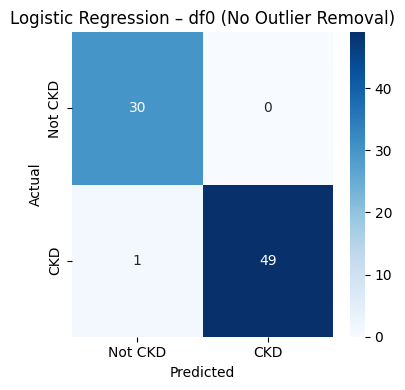

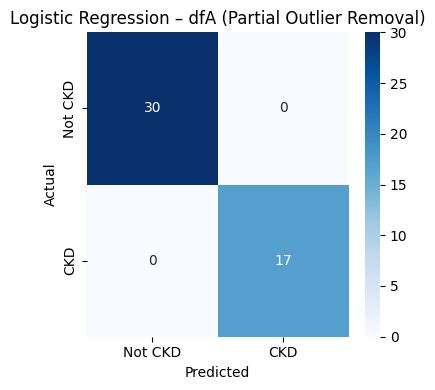

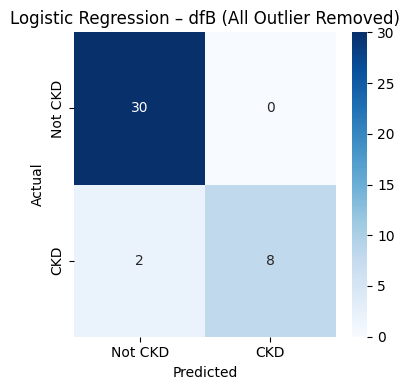

In [46]:
plot_cm(
    lr0,
    Xte0, yte0,
    "Logistic Regression – df0 (No Outlier Removal)"
)
plot_cm(
    lrA,
    XteA, yteA,
    "Logistic Regression – dfA (Partial Outlier Removal)"
)
plot_cm(
    lrB,
    XteB, yteB,
    "Logistic Regression – dfB (All Outlier Removed)"
)


## Decision Tree

In [47]:

dt0 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt0.fit(Xtr0, ytr0)

evaluate_model(dt0, Xtr0, ytr0, "Train Set - df0 (No Outlier Removal)")
evaluate_model(dt0, Xte0, yte0, "Test Set - df0 (No Outlier Removal)")

dtA = DecisionTreeClassifier(max_depth=5, random_state=42)
dtA.fit(XtrA, ytrA)

evaluate_model(dtA, XtrA, ytrA, "Train Set - dfA (Partial Outlier Removal)")
evaluate_model(dtA, XteA, yteA, "Test Set - dfA (Partial Outlier Removal)")

dtB = DecisionTreeClassifier(max_depth=5, random_state=42)
dtB.fit(XtrB, ytrB)

evaluate_model(dtB, XtrB, ytrB, "Train Set - dfB (All Outlier Removed)")
evaluate_model(dtB, XteB, yteB, "Test Set - dfB (All Outlier Removed)")



===== Train Set - df0 (No Outlier Removal) Evaluation =====
Accuracy:  99.69%
Precision: 99.69%
Recall:    99.69%
F1 Score:  99.69%
ROC AUC:   99.97%

===== Test Set - df0 (No Outlier Removal) Evaluation =====
Accuracy:  98.75%
Precision: 98.79%
Recall:    98.75%
F1 Score:  98.75%
ROC AUC:   99.00%

===== Train Set - dfA (Partial Outlier Removal) Evaluation =====
Accuracy:  99.46%
Precision: 99.47%
Recall:    99.46%
F1 Score:  99.46%
ROC AUC:   99.95%

===== Test Set - dfA (Partial Outlier Removal) Evaluation =====
Accuracy:  97.87%
Precision: 97.94%
Recall:    97.87%
F1 Score:  97.86%
ROC AUC:   97.06%

===== Train Set - dfB (All Outlier Removed) Evaluation =====
Accuracy:  100.00%
Precision: 100.00%
Recall:    100.00%
F1 Score:  100.00%
ROC AUC:   100.00%

===== Test Set - dfB (All Outlier Removed) Evaluation =====
Accuracy:  90.00%
Precision: 89.84%
Recall:    90.00%
F1 Score:  89.61%
ROC AUC:   83.33%


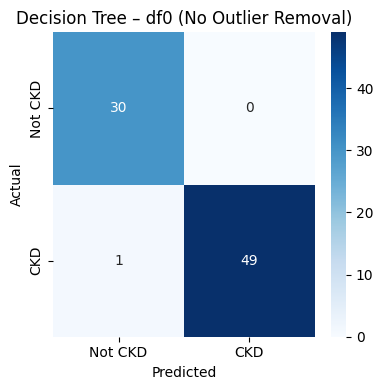

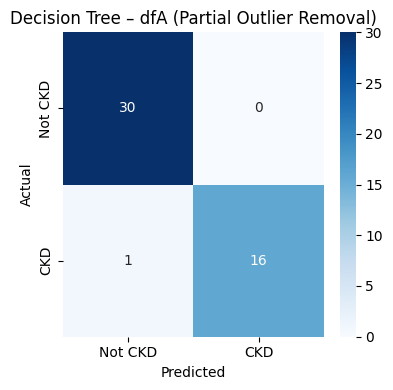

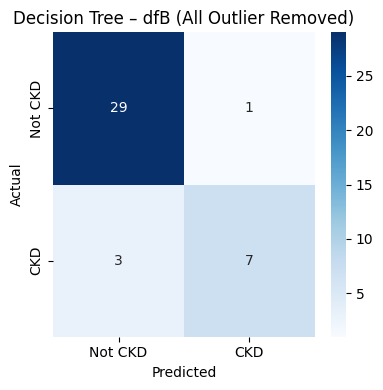

In [48]:
plot_cm(
    dt0, Xte0, yte0,
    "Decision Tree – df0 (No Outlier Removal)"
)
plot_cm(
    dtA, XteA, yteA,
    "Decision Tree – dfA (Partial Outlier Removal)"
)
plot_cm(
    dtB, XteB, yteB,
    "Decision Tree – dfB (All Outlier Removed)"
)


## Naive Bayes

In [49]:
nb0 = GaussianNB()
nb0.fit(Xtr0, ytr0)

evaluate_model(nb0, Xtr0, ytr0, "Train Set - df0 (No Outlier Removal)")
evaluate_model(nb0, Xte0, yte0, "Test Set - df0 (No Outlier Removal)")

nbA = GaussianNB()
nbA.fit(XtrA, ytrA)

evaluate_model(nbA, XtrA, ytrA, "Train Set - dfA (Partial Outlier Removal)")
evaluate_model(nbA, XteA, yteA, "Test Set - dfA (Partial Outlier Removal)")

nbB = GaussianNB()
nbB.fit(XtrB, ytrB)

evaluate_model(nbB, XtrB, ytrB, "Train Set - dfB (All Outlier Removed)")
evaluate_model(nbB, XteB, yteB, "Test Set - dfB (All Outlier Removed)")



===== Train Set - df0 (No Outlier Removal) Evaluation =====
Accuracy:  96.25%
Precision: 96.59%
Recall:    96.25%
F1 Score:  96.28%
ROC AUC:   100.00%

===== Test Set - df0 (No Outlier Removal) Evaluation =====
Accuracy:  97.50%
Precision: 97.66%
Recall:    97.50%
F1 Score:  97.51%
ROC AUC:   100.00%

===== Train Set - dfA (Partial Outlier Removal) Evaluation =====
Accuracy:  96.77%
Precision: 96.93%
Recall:    96.77%
F1 Score:  96.74%
ROC AUC:   100.00%

===== Test Set - dfA (Partial Outlier Removal) Evaluation =====
Accuracy:  93.62%
Precision: 94.20%
Recall:    93.62%
F1 Score:  93.46%
ROC AUC:   100.00%

===== Train Set - dfB (All Outlier Removed) Evaluation =====
Accuracy:  96.18%
Precision: 96.36%
Recall:    96.18%
F1 Score:  96.06%
ROC AUC:   100.00%

===== Test Set - dfB (All Outlier Removed) Evaluation =====
Accuracy:  92.50%
Precision: 93.18%
Recall:    92.50%
F1 Score:  92.02%
ROC AUC:   100.00%


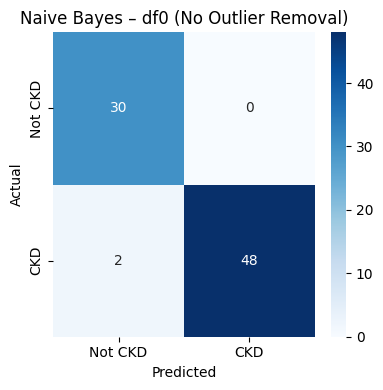

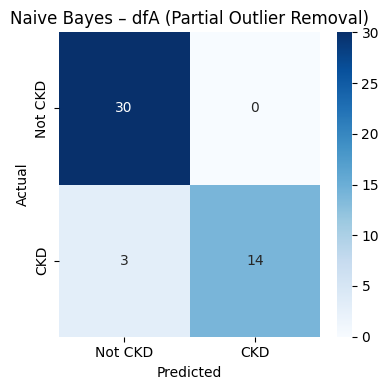

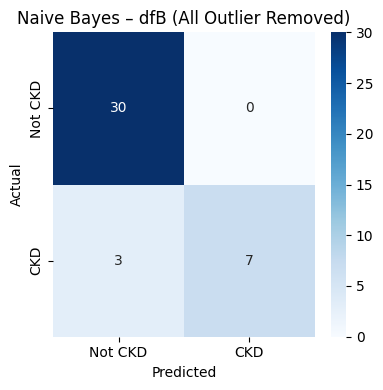

In [50]:
plot_cm(
    nb0, Xte0, yte0,
    "Naive Bayes – df0 (No Outlier Removal)"
)
plot_cm(
    nbA, XteA, yteA,
    "Naive Bayes – dfA (Partial Outlier Removal)"
)
plot_cm(
    nbB, XteB, yteB,
    "Naive Bayes – dfB (All Outlier Removed)"
)


In [51]:
def get_test_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average='weighted', zero_division=0),
    }

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        if y_proba.shape[1] == 2:
            metrics["ROC AUC"] = roc_auc_score(y_test, y_proba[:, 1])
    else:
        metrics["ROC AUC"] = None

    return metrics

In [52]:
results = []
# ========== Logistic Regression ==========
results.append({
    "Model": "Logistic Regression",
    "Outlier Condition": "df0 (No Removal)",
    **get_test_metrics(lr0, Xte0, yte0)
})

results.append({
    "Model": "Logistic Regression",
    "Outlier Condition": "dfA (Partial Removal)",
    **get_test_metrics(lrA, XteA, yteA)
})

results.append({
    "Model": "Logistic Regression",
    "Outlier Condition": "dfB (All Removed)",
    **get_test_metrics(lrB, XteB, yteB)
})

# ========== Decision Tree ==========
results.append({
    "Model": "Decision Tree",
    "Outlier Condition": "df0 (No Removal)",
    **get_test_metrics(dt0, Xte0, yte0)
})

results.append({
    "Model": "Decision Tree",
    "Outlier Condition": "dfA (Partial Removal)",
    **get_test_metrics(dtA, XteA, yteA)
})

results.append({
    "Model": "Decision Tree",
    "Outlier Condition": "dfB (All Removed)",
    **get_test_metrics(dtB, XteB, yteB)
})

# ========== Naive Bayes ==========
results.append({
    "Model": "Naive Bayes",
    "Outlier Condition": "df0 (No Removal)",
    **get_test_metrics(nb0, Xte0, yte0)
})

results.append({
    "Model": "Naive Bayes",
    "Outlier Condition": "dfA (Partial Removal)",
    **get_test_metrics(nbA, XteA, yteA)
})

results.append({
    "Model": "Naive Bayes",
    "Outlier Condition": "dfB (All Removed)",
    **get_test_metrics(nbB, XteB, yteB)
})

df_results = pd.DataFrame(results)
df_results


,Model,Outlier Condition,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Logistic Regression,df0 (No Removal),0.987500,0.987903,0.987500,0.987539,1.000000
1,Logistic Regression,dfA (Partial Removal),1.000000,1.000000,1.000000,1.000000,1.000000
2,Logistic Regression,dfB (All Removed),0.950000,0.953125,0.950000,0.948029,1.000000
3,Decision Tree,df0 (No Removal),0.987500,0.987903,0.987500,0.987539,0.990000
4,Decision Tree,dfA (Partial Removal),0.978723,0.979410,0.978723,0.978575,0.970588
5,Decision Tree,dfB (All Removed),0.900000,0.898438,0.900000,0.896057,0.833333
6,Naive Bayes,df0 (No Removal),0.975000,0.976562,0.975000,0.975148,1.000000
7,Naive Bayes,dfA (Partial Removal),0.936170,0.941973,0.936170,0.934601,1.000000
8,Naive Bayes,dfB (All Removed),0.925000,0.931818,0.925000,0.920168,1.000000


<Figure size 1000x600 with 0 Axes>

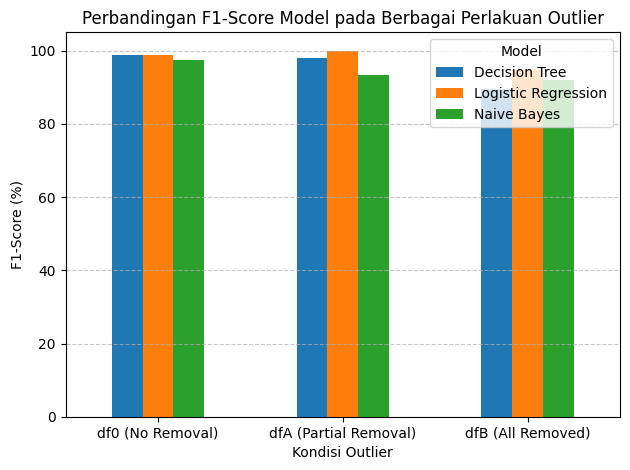

In [53]:
df_plot = df_results.copy()

# pastikan semua metrik jadi persen
for col in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC"]:
    if col in df_plot.columns:
        df_plot[col] = df_plot[col] * 100

plot_df_f1 = df_plot.pivot(
    index="Outlier Condition",
    columns="Model",
    values="F1-Score"
)

plt.figure(figsize=(10, 6))
plot_df_f1.plot(kind="bar")

plt.title("Perbandingan F1-Score Model pada Berbagai Perlakuan Outlier")
plt.ylabel("F1-Score (%)")
plt.xlabel("Kondisi Outlier")
plt.xticks(rotation=0)
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Model")

plt.tight_layout()
plt.show()


Berdasarkan hasil eksperimen, model Logistic Regression yang diterapkan pada data dengan partial outlier removal (dfA) menunjukkan performa paling optimal, dengan nilai akurasi, precision, recall, dan F1-score masing-masing mencapai 100%. Temuan ini mengindikasikan bahwa penghapusan sebagian outlier dapat meningkatkan kinerja model secara signifikan tanpa menghilangkan informasi penting yang terkandung dalam data.

#### Hyperparameter Tuning Logistic Regression

In [54]:
X_train = Xtr0
y_train = ytr0
X_test  = Xte0
y_test  = yte0

# ===========================
# GA PARAMETERS
# ===========================
POP_SIZE = 20
GENERATIONS = 30
MUTATION_RATE = 0.2
ELITE_SIZE = 1

# Logistic Regression search space
C_RANGE = (0.001, 10.0)
PENALTY_OPTIONS = ["l2"]   # aman untuk semua solver
SOLVER_OPTIONS = ["lbfgs", "liblinear"]

def create_chromosome():
    return {
        "C": round(random.uniform(*C_RANGE), 4),
        "penalty": random.choice(PENALTY_OPTIONS),
        "solver": random.choice(SOLVER_OPTIONS)
    }

def fitness(chromosome):
    model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        **chromosome
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    return scores.mean()

def tournament_selection(population, fitnesses, k=3):
    candidates = random.sample(list(zip(population, fitnesses)), k)
    return max(candidates, key=lambda x: x[1])[0]

def crossover(parent1, parent2):
    return {
        "C": parent1["C"] if random.random() < 0.5 else parent2["C"],
        "penalty": parent1["penalty"] if random.random() < 0.5 else parent2["penalty"],
        "solver": parent1["solver"] if random.random() < 0.5 else parent2["solver"]
    }

def mutate(chromosome):
    gene = random.choice(["C", "solver"])

    if gene == "C":
        chromosome["C"] = round(random.uniform(*C_RANGE), 4)
    else:
        chromosome["solver"] = random.choice(SOLVER_OPTIONS)

    return chromosome

population = [create_chromosome() for _ in range(POP_SIZE)]
best_scores = []

for gen in range(GENERATIONS):
    fitnesses = [fitness(ind) for ind in population]

    # ---- ELITISM ----
    elite_indices = np.argsort(fitnesses)[-ELITE_SIZE:]
    elites = [population[i] for i in elite_indices]

    new_population = elites.copy()

    # ---- Generate New Population ----
    while len(new_population) < POP_SIZE:
        parent1 = tournament_selection(population, fitnesses)
        parent2 = tournament_selection(population, fitnesses)

        child = crossover(parent1, parent2)

        if random.random() < MUTATION_RATE:
            child = mutate(child)

        new_population.append(child)

    population = new_population

    best_fitness = max(fitnesses)
    best_individual = population[np.argmax(fitnesses)]
    best_scores.append(best_fitness)

    print(
        f"Gen {gen+1}/{GENERATIONS} | "
        f"Best CV Accuracy = {best_fitness:.4f} | "
        f"Params = {best_individual}"
    )


Gen 1/30 | Best CV Accuracy = 0.9969 | Params = {'C': 1.274, 'penalty': 'l2', 'solver': 'lbfgs'}
Gen 2/30 | Best CV Accuracy = 0.9969 | Params = {'C': 2.0167, 'penalty': 'l2', 'solver': 'lbfgs'}
Gen 3/30 | Best CV Accuracy = 0.9969 | Params = {'C': 1.9888, 'penalty': 'l2', 'solver': 'lbfgs'}
Gen 4/30 | Best CV Accuracy = 0.9969 | Params = {'C': 1.2737, 'penalty': 'l2', 'solver': 'lbfgs'}
Gen 5/30 | Best CV Accuracy = 0.9969 | Params = {'C': 1.274, 'penalty': 'l2', 'solver': 'lbfgs'}
Gen 6/30 | Best CV Accuracy = 0.9969 | Params = {'C': 1.1521, 'penalty': 'l2', 'solver': 'lbfgs'}
Gen 7/30 | Best CV Accuracy = 0.9969 | Params = {'C': 1.1521, 'penalty': 'l2', 'solver': 'lbfgs'}
Gen 8/30 | Best CV Accuracy = 0.9969 | Params = {'C': 1.274, 'penalty': 'l2', 'solver': 'lbfgs'}
Gen 9/30 | Best CV Accuracy = 0.9969 | Params = {'C': 1.274, 'penalty': 'l2', 'solver': 'lbfgs'}
Gen 10/30 | Best CV Accuracy = 0.9969 | Params = {'C': 1.1521, 'penalty': 'l2', 'solver': 'lbfgs'}
Gen 11/30 | Best CV Acc

In [55]:
fitnesses = [fitness(ind) for ind in population]
best_idx = np.argmax(fitnesses)
best_params_lr = population[best_idx]

print("\nBEST HYPERPARAMETERS (GA - Logistic Regression):")
print(best_params_lr)
print(f"Best CV Accuracy: {fitnesses[best_idx]:.4f}")

best_lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    **best_params_lr
)

best_lr.fit(X_train, y_train)

y_pred = best_lr.predict(X_test)

print("\n===== FINAL LOGISTIC REGRESSION (GA) – TEST SET =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


BEST HYPERPARAMETERS (GA - Logistic Regression):
{'C': 1.1521, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Accuracy: 0.9969

===== FINAL LOGISTIC REGRESSION (GA) – TEST SET =====
Accuracy: 0.9875

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



#### Hyperparameter Tuning Decision Tree

In [56]:
X_train = Xtr0
y_train = ytr0
X_test  = Xte0
y_test  = yte0

# ===========================
# GA PARAMETERS
# ===========================
POP_SIZE = 20
GENERATIONS = 30
MUTATION_RATE = 0.2
ELITE_SIZE = 1

MAX_DEPTH_RANGE = (2, 20)
MIN_SPLIT_RANGE = (2, 20)
MIN_LEAF_RANGE  = (1, 10)
CRITERION_OPTIONS = ["gini", "entropy"]

def create_chromosome():
    return {
        "max_depth": random.randint(*MAX_DEPTH_RANGE),
        "min_samples_split": random.randint(*MIN_SPLIT_RANGE),
        "min_samples_leaf": random.randint(*MIN_LEAF_RANGE),
        "criterion": random.choice(CRITERION_OPTIONS)
    }

def fitness(chromosome):
    model = DecisionTreeClassifier(
        random_state=42,
        **chromosome
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    return scores.mean()
    
def tournament_selection(population, fitnesses, k=3):
    candidates = random.sample(list(zip(population, fitnesses)), k)
    return max(candidates, key=lambda x: x[1])[0]

def crossover(parent1, parent2):
    return {
        "max_depth": parent1["max_depth"] if random.random() < 0.5 else parent2["max_depth"],
        "min_samples_split": parent1["min_samples_split"] if random.random() < 0.5 else parent2["min_samples_split"],
        "min_samples_leaf": parent1["min_samples_leaf"] if random.random() < 0.5 else parent2["min_samples_leaf"],
        "criterion": parent1["criterion"] if random.random() < 0.5 else parent2["criterion"]
    }

def mutate(chromosome):
    gene = random.choice(
        ["max_depth", "min_samples_split", "min_samples_leaf", "criterion"]
    )

    if gene == "max_depth":
        chromosome["max_depth"] = random.randint(*MAX_DEPTH_RANGE)
    elif gene == "min_samples_split":
        chromosome["min_samples_split"] = random.randint(*MIN_SPLIT_RANGE)
    elif gene == "min_samples_leaf":
        chromosome["min_samples_leaf"] = random.randint(*MIN_LEAF_RANGE)
    else:
        chromosome["criterion"] = random.choice(CRITERION_OPTIONS)

    return chromosome

population = [create_chromosome() for _ in range(POP_SIZE)]
best_scores = []

for gen in range(GENERATIONS):
    fitnesses = [fitness(ind) for ind in population]

    # ---- ELITISM ----
    elite_indices = np.argsort(fitnesses)[-ELITE_SIZE:]
    elites = [population[i] for i in elite_indices]

    new_population = elites.copy()

    # ---- Generate New Population ----
    while len(new_population) < POP_SIZE:
        parent1 = tournament_selection(population, fitnesses)
        parent2 = tournament_selection(population, fitnesses)

        child = crossover(parent1, parent2)

        if random.random() < MUTATION_RATE:
            child = mutate(child)

        new_population.append(child)

    population = new_population

    best_fitness = max(fitnesses)
    best_individual = population[np.argmax(fitnesses)]
    best_scores.append(best_fitness)

    print(
        f"Gen {gen+1}/{GENERATIONS} | "
        f"Best CV Accuracy = {best_fitness:.4f} | "
        f"Params = {best_individual}"
    )

fitnesses = [fitness(ind) for ind in population]
best_idx = np.argmax(fitnesses)
best_params = population[best_idx]

print("\nBEST HYPERPARAMETERS (GA):")
print(best_params)
print(f"Best CV Accuracy: {fitnesses[best_idx]:.4f}")

best_dt = DecisionTreeClassifier(
    random_state=42,
    **best_params
)




Gen 1/30 | Best CV Accuracy = 0.9625 | Params = {'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 5, 'criterion': 'entropy'}
Gen 2/30 | Best CV Accuracy = 0.9625 | Params = {'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 9, 'criterion': 'entropy'}
Gen 3/30 | Best CV Accuracy = 0.9625 | Params = {'max_depth': 11, 'min_samples_split': 8, 'min_samples_leaf': 10, 'criterion': 'entropy'}
Gen 4/30 | Best CV Accuracy = 0.9625 | Params = {'max_depth': 7, 'min_samples_split': 14, 'min_samples_leaf': 9, 'criterion': 'entropy'}
Gen 5/30 | Best CV Accuracy = 0.9688 | Params = {'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 9, 'criterion': 'entropy'}
Gen 6/30 | Best CV Accuracy = 0.9688 | Params = {'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 1, 'criterion': 'entropy'}
Gen 7/30 | Best CV Accuracy = 0.9750 | Params = {'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 9, 'criterion': 'entropy'}
Gen 8/30 | Best CV Accuracy = 0.9750 | P

In [57]:
best_dt.fit(X_train, y_train)

y_pred = best_dt.predict(X_test)

print("\n===== FINAL MODEL PERFORMANCE (TEST SET) =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


===== FINAL MODEL PERFORMANCE (TEST SET) =====
Accuracy: 0.9875

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



Hasil optimasi menggunakan Genetic Algorithm menunjukkan bahwa nilai akurasi cross-validation tertinggi, yaitu 97,5%, telah tercapai sejak generasi awal dan cenderung stabil hingga generasi akhir. Kondisi ini mengindikasikan adanya beberapa kombinasi hyperparameter yang menghasilkan performa yang relatif setara. Parameter terbaik yang dipilih menunjukkan struktur pohon dengan kedalaman yang tidak terlalu dalam, sehingga model diharapkan memiliki kemampuan generalisasi yang lebih baik terhadap data baru.

#### Hyperparameter Tuning Naive Bayes

In [58]:
X_train = Xtr0
y_train = ytr0
X_test  = Xte0
y_test  = yte0

# ===========================
# GA PARAMETERS
# ===========================
POP_SIZE = 20
GENERATIONS = 30
MUTATION_RATE = 0.2
ELITE_SIZE = 1

# var_smoothing biasanya kecil banget, kita cari dalam skala log
# contoh: 1e-12 sampai 1e-6
LOG_VAR_SMOOTH_RANGE = (-12, -6)

# ===========================
# GA FUNCTIONS
# ===========================
def create_chromosome():
    log_vs = random.uniform(*LOG_VAR_SMOOTH_RANGE)
    return {"var_smoothing": 10**log_vs}

def fitness(chromosome):
    model = GaussianNB(**chromosome)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    return scores.mean()

def tournament_selection(population, fitnesses, k=3):
    candidates = random.sample(list(zip(population, fitnesses)), k)
    return max(candidates, key=lambda x: x[1])[0]

def crossover(parent1, parent2):
    # karena cuma 1 gen, crossover pilih salah satu
    return parent1.copy() if random.random() < 0.5 else parent2.copy()

def mutate(chromosome):
    log_vs = random.uniform(*LOG_VAR_SMOOTH_RANGE)
    chromosome["var_smoothing"] = 10**log_vs
    return chromosome

# ===========================
# INIT POPULATION
# ===========================
population = [create_chromosome() for _ in range(POP_SIZE)]
best_scores = []

# ===========================
# GA LOOP (with Elitism)
# ===========================
for gen in range(GENERATIONS):
    fitnesses = [fitness(ind) for ind in population]

    # elitism
    elite_indices = np.argsort(fitnesses)[-ELITE_SIZE:]
    elites = [population[i] for i in elite_indices]

    new_population = elites.copy()

    while len(new_population) < POP_SIZE:
        parent1 = tournament_selection(population, fitnesses)
        parent2 = tournament_selection(population, fitnesses)

        child = crossover(parent1, parent2)

        if random.random() < MUTATION_RATE:
            child = mutate(child)

        new_population.append(child)

    population = new_population

    best_fitness = max(fitnesses)
    best_individual = population[np.argmax(fitnesses)]
    best_scores.append(best_fitness)

    print(
        f"Gen {gen+1}/{GENERATIONS} | "
        f"Best CV Accuracy = {best_fitness:.4f} | "
        f"Params = {best_individual}"
    )

# ===========================
# FINAL RESULT (train -> test)
# ===========================
fitnesses = [fitness(ind) for ind in population]
best_idx = np.argmax(fitnesses)
best_params_nb = population[best_idx]

print("\nBEST HYPERPARAMETERS (GA - GaussianNB):")
print(best_params_nb)
print(f"Best CV Accuracy: {fitnesses[best_idx]:.4f}")

best_nb = GaussianNB(**best_params_nb)
best_nb.fit(X_train, y_train)
y_pred = best_nb.predict(X_test)

print("\n===== FINAL NAIVE BAYES (GA) – TEST SET =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Gen 1/30 | Best CV Accuracy = 0.9625 | Params = {'var_smoothing': 1.6255512043873485e-07}
Gen 2/30 | Best CV Accuracy = 0.9625 | Params = {'var_smoothing': 2.9728743264560054e-09}
Gen 3/30 | Best CV Accuracy = 0.9625 | Params = {'var_smoothing': 1.0643948832903181e-11}
Gen 4/30 | Best CV Accuracy = 0.9625 | Params = {'var_smoothing': 8.131600965779508e-09}
Gen 5/30 | Best CV Accuracy = 0.9625 | Params = {'var_smoothing': 1.6255512043873485e-07}
Gen 6/30 | Best CV Accuracy = 0.9625 | Params = {'var_smoothing': 9.453741787985828e-11}
Gen 7/30 | Best CV Accuracy = 0.9625 | Params = {'var_smoothing': 3.2578042564235824e-07}
Gen 8/30 | Best CV Accuracy = 0.9625 | Params = {'var_smoothing': 1.263652812612012e-10}
Gen 9/30 | Best CV Accuracy = 0.9625 | Params = {'var_smoothing': 3.2578042564235824e-07}
Gen 10/30 | Best CV Accuracy = 0.9625 | Params = {'var_smoothing': 1.9604119819249552e-11}
Gen 11/30 | Best CV Accuracy = 0.9625 | Params = {'var_smoothing': 5.95827447654382e-08}
Gen 12/30 | B

In [59]:
evaluate_model(best_dt, Xte0, yte0, "DT (GA) – Test df0")
evaluate_model(best_lr, Xte0, yte0, "LR (GA) – Test df0")
evaluate_model(best_nb, Xte0, yte0, "NB (GA) – Test df0")



===== DT (GA) – Test df0 Evaluation =====
Accuracy:  98.75%
Precision: 98.79%
Recall:    98.75%
F1 Score:  98.75%
ROC AUC:   99.00%

===== LR (GA) – Test df0 Evaluation =====
Accuracy:  98.75%
Precision: 98.79%
Recall:    98.75%
F1 Score:  98.75%
ROC AUC:   100.00%

===== NB (GA) – Test df0 Evaluation =====
Accuracy:  97.50%
Precision: 97.66%
Recall:    97.50%
F1 Score:  97.51%
ROC AUC:   100.00%


Berdasarkan hasil evaluasi pada dataset tanpa proses penghapusan outlier, model Logistic Regression dengan pengaturan hyperparameter hasil optimasi Genetic Algorithm menunjukkan kinerja paling unggul. Model ini mencapai nilai akurasi dan F1-score sebesar 98,75%, serta ROC AUC sebesar 100%, yang mengindikasikan kemampuan klasifikasi yang sangat baik.

## Kesimpulan

Model dengan nilai akurasi tertinggi diperoleh dari Logistic Regression tanpa proses hyperparameter tuning yang diterapkan pada data dengan perlakuan partial outlier removal, di mana model tersebut mampu mencapai kinerja sempurna pada seluruh metrik evaluasi. Hasil ini menunjukkan bahwa penghapusan sebagian outlier dapat meningkatkan kualitas data sekaligus mempermudah proses pemisahan kelas oleh model.

Sebaliknya, Logistic Regression yang dioptimasi menggunakan Genetic Algorithm menunjukkan performa yang relatif setara ketika diterapkan pada dataset tanpa penghapusan outlier. Meskipun peningkatan akurasi yang dihasilkan tidak signifikan, model hasil optimasi memiliki tingkat stabilitas yang lebih baik dan mampu mempertahankan kinerja tinggi pada data yang lebih merepresentasikan kondisi asli. Temuan ini mengindikasikan bahwa Genetic Algorithm berperan dalam menentukan konfigurasi parameter yang optimal dan lebih robust, khususnya saat model dihadapkan pada data dengan tingkat variasi yang lebih kompleks.